In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

from morl_behavior_objective.analysis.metrics_clean import compute_zadu_metrics
from morl_behavior_objective.utils import get_pareto_front
from morl_behavior_objective.utils import load_transformer_embeddings
from morl_behavior_objective.utils import render_policy

# Set matplotlib parameters
mpl.rcParams["pdf.fonttype"] = 42  # use true-type
mpl.rcParams["ps.fonttype"] = 42  # use true-type
mpl.rcParams["font.size"] = 18
mpl.rcParams["lines.linewidth"] = 2.2
mpl.rcParams["text.latex.preamble"] = r"\usepackage{amsmath,amssymb,underscore}"
mpl.rcParams["text.usetex"] = True
mpl.rcParams["xtick.labelsize"] = 18
mpl.rcParams["ytick.labelsize"] = 18
mpl.rcParams["axes.titlesize"] = 18
mpl.rcParams["axes.labelsize"] = 18
mpl.rcParams["legend.fontsize"] = 16

colors = [
    "#5CB5FF",
    "#D55E00",
    "#009E73",
    "#e6194b",
]

/Users/zuzannaosika/miniforge3/envs/env_py11/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
/Users/zuzannaosika/miniforge3/envs/env_py11/lib/python3.11/site-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment deep-sea-treasure-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/Users/zuzannaosika/miniforge3/envs/env_py11/lib/python3.11/site-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment deep-sea-treasure-concave-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/Users/zuzannaosika/miniforge3/envs/env_py11/lib/pyth

## Load all the data

### Load all environments

In [2]:
seed = 0

# Configuration for environments
environments = {
    "cheetah": {
        "trajectory_dir": "../../trajectories/morld/mo-halfcheetah-v4_100steps/seed0",
        "pareto_size": 80,
        "embedding_path": "../../trajectories/morld/mo-halfcheetah-v4_100steps/embeddings/mo-halfcheetah-v4_100steps_3D_l2_embeddings_e251_pf_t_ts100_shorter.json",
    },
    "highway": {
        "trajectory_dir": "../../trajectories/morld/mo-highway-fast-v0_100steps_test",
        "pareto_size": 41,
        "embedding_path": "../../trajectories/morld/mo-highway-fast-v0_100steps_test/embeddings/mo-highway-fast-v0_100steps_3D_l2_embeddings_e501_pf_t_shorter.json",
    },
    "hopper_2d": {
        "trajectory_dir": "../../trajectories/morld/mo-hopper-2obj-v5",
        "pareto_size": 34,
        "embedding_path": "../../trajectories/morld/mo-hopper-2obj-v5/embeddings/mo-hopper-2obj-v5_3D_l2_embeddings_e501_pf_t_shorter.json",
    },
    "hopper_3d": {
        "trajectory_dir": "../../trajectories/morld/mo-hopper-v5",
        "pareto_size": 159,
        "embedding_path": "../../trajectories/morld/mo-hopper-v5/embeddings/mo-hopper-v5_3D_l2_embeddings_e501_pf_t_shorter.json",
    },
}

# Load returns (Pareto fronts)
returns = get_pareto_front(environments["cheetah"]["trajectory_dir"], pareto_size=environments["cheetah"]["pareto_size"])

returns_highway = get_pareto_front(
    environments["highway"]["trajectory_dir"], pareto_size=environments["highway"]["pareto_size"]
)

returns_hopper_2d = get_pareto_front(
    environments["hopper_2d"]["trajectory_dir"], pareto_size=environments["hopper_2d"]["pareto_size"]
)

returns_hopper_3d = get_pareto_front(
    environments["hopper_3d"]["trajectory_dir"], pareto_size=environments["hopper_3d"]["pareto_size"]
)

# Load transformer embeddings
all_t_emb_cheetah, _ = load_transformer_embeddings(environments["cheetah"]["embedding_path"])
all_t_emb_high, _ = load_transformer_embeddings(environments["highway"]["embedding_path"])
all_t_emb_hopper_2d, _ = load_transformer_embeddings(environments["hopper_2d"]["embedding_path"])
all_t_emb_hopper_3d, _ = load_transformer_embeddings(environments["hopper_3d"]["embedding_path"])

print("Data loaded successfully:")
print(f" Cheetah: returns shape: {returns.shape}, embeddings shape: {all_t_emb_cheetah.shape}")
print(f" Highway: returns shape: {returns_highway.shape}, embeddings shape: {all_t_emb_high.shape}")
print(f" Hopper 2D: returns shape: {returns_hopper_2d.shape}, embeddings shape: {all_t_emb_hopper_2d.shape}")
print(f" Hopper 3D: returns shape: {returns_hopper_3d.shape}, embeddings shape: {all_t_emb_hopper_3d.shape}")

TypeError: get_pareto_front() got an unexpected keyword argument 'pareto_size'

## Trustworthiness and Continuity

In [ ]:
print("\n--- RAW METRICS ---")
print("Returns vs highway embedding:", compute_zadu_metrics(returns_highway, all_t_emb_high))
print(" Returns vs cheeta embedding:", compute_zadu_metrics(returns, all_t_emb_cheetah))


--- RAW METRICS ---
ZADU metrics computed successfully
Returns vs highway embedding: [{'trustworthiness': 0.7372357723577235, 'continuity': 0.7778861788617887}, {'mrre_false': 0.7236461347664324, 'mrre_missing': 0.7649855312112442}]
ZADU metrics computed successfully
 Returns vs cheeta embedding: [{'trustworthiness': 0.9768790849673203, 'continuity': 0.9829248366013073}, {'mrre_false': 0.9715425531914892, 'mrre_missing': 0.9763297872340425}]


In [6]:
from typing import List
class Solution:
    def sortArrayByParity(self, nums: List[int]) -> List[int]:
        if len(nums)<=1:
            return nums
        left=0
        for right in range(len(nums)):
            print(left,right)
            if nums[right]%2==0:
                temp=nums[left]
                nums[left]=nums[right]
                if left!=right and temp!=nums[right]:
                    nums[right]=temp
                left=+1
        return nums
sol=Solution()
sol.sortArrayByParity([0,2,1,4])

0 0
1 1
1 2
1 3


[0, 4, 1, 2]

### Visualize embeddings

In [ ]:
# import numpy as np
# import pandas as pd
# import plotly.graph_objects as go

# # --- assume you already have these numpy arrays ---
# # returns: shape (N, 2)
# # embeddings: shape (N, 3) or (N, D)
# # example for testing:
# # returns = np.random.rand(50, 2)
# # embeddings = np.random.rand(50, 3)

# # --- Sort lexicographically and keep mapping ---
# sort_idx = np.lexsort(returns.T)
# sorted_pf = returns[sort_idx]

# # --- Build dataframe ---
# df = pd.DataFrame({
#     "obj1": sorted_pf[:, 0],
#     "obj2": sorted_pf[:, 1],
#     "rank": np.arange(len(sort_idx)),     # new ordered index
#     "orig_idx": sort_idx                  # original index
# })

# # --- 2D Pareto frontier visualization ---
# fig2d = go.Figure()

# fig2d.add_trace(go.Scatter(
#     x=df["obj1"],
#     y=df["obj2"],
#     mode="markers+text",
#     text=df["rank"].astype(str),
#     textposition="top center",
#     marker=dict(size=8, color="crimson"),
#     customdata=np.stack([df["rank"], df["orig_idx"]], axis=-1),
#     hovertemplate=(
#         "new idx (rank)=%{customdata[0]}<br>"
#         "original idx=%{customdata[1]}<br>"
#         "obj1=%{x:.3f}<br>"
#         "obj2=%{y:.3f}<extra></extra>"
#     ),
#     name="Pareto (sorted)"
# ))

# fig2d.update_layout(
#     width=800, height=600,
#     title="Sorted Pareto Frontier (labels = new ordered indices)",
#     xaxis_title="Objective 1",
#     yaxis_title="Objective 2"
# )

# fig2d.write_html("cheetah.html")
# fig2d.show()


# # --- 3D embeddings visualization aligned with sorted indices ---
# emb3 = all_t_e100[:, :3]           # take first 3 dims if more
# emb3_sorted = emb3[sort_idx]       # reorder same as returns

# fig3d = go.Figure()

# # points labeled by new sorted index
# fig3d.add_trace(go.Scatter3d(
#     x=emb3_sorted[:, 0],
#     y=emb3_sorted[:, 1],
#     z=emb3_sorted[:, 2],
#     mode="markers+text",
#     text=df["rank"].astype(str),
#     textposition="top center",
#     marker=dict(
#         size=4,
#         color=df["rank"],
#         colorscale="Viridis",
#         colorbar=dict(title="rank")
#     ),
#     customdata=np.stack([df["rank"], df["orig_idx"]], axis=-1),
#     hovertemplate=(
#         "new idx (rank)=%{customdata[0]}<br>"
#         "original idx=%{customdata[1]}<br>"
#         "x=%{x:.3f}<br>"
#         "y=%{y:.3f}<br>"
#         "z=%{z:.3f}<extra></extra>"
#     ),
#     name="Embeddings (sorted)"
# ))


# fig3d.update_layout(
#     width=900, height=700,
#     title="3D Embeddings (aligned with sorted Pareto indices)",
#     scene=dict(
#         xaxis_title="Embedding dim 1",
#         yaxis_title="Embedding dim 2",
#         zaxis_title="Embedding dim 3"
#     )
# )

# fig3d.write_html("cheetah_3d_embeddings.html")
# fig3d.show()


## Lipschitz Histograms


Computing Lipschitz constant between policy 0 and 1
2.825950643170885
0.001172939142801418
Lipshitz: 0.0004150600243623896
Lipschitz constant for policy 0 ([ 310.74908793 -108.12961902], [-0.14808081 -0.40138254  0.90373647]) to 1 ([ 309.29723363 -105.70513637], [-0.14890546 -0.40057158  0.90393168]): 0.0004150600243623896, d_obj: 2.825950643170885, d_emb: 0.001172939142801418
Computing Lipschitz constant between policy 1 and 2
2.7746412039307944
0.002671346261721396
Lipshitz: 0.0009627717839470337
Lipschitz constant for policy 1 ([ 309.29723363 -105.70513637], [-0.14890546 -0.40057158  0.90393168]) to 2 ([ 306.52434554 -105.60651863], [-0.15079536 -0.39875403  0.90444243]): 0.0009627717839470337, d_obj: 2.7746412039307944, d_emb: 0.002671346261721396
Computing Lipschitz constant between policy 2 and 3
1.2389537465973897
0.014266896105222845
Lipshitz: 0.011515277422103003
Lipschitz constant for policy 2 ([ 306.52434554 -105.60651863], [-0.15079536 -0.39875403  0.90444243]) to 3 ([ 306.

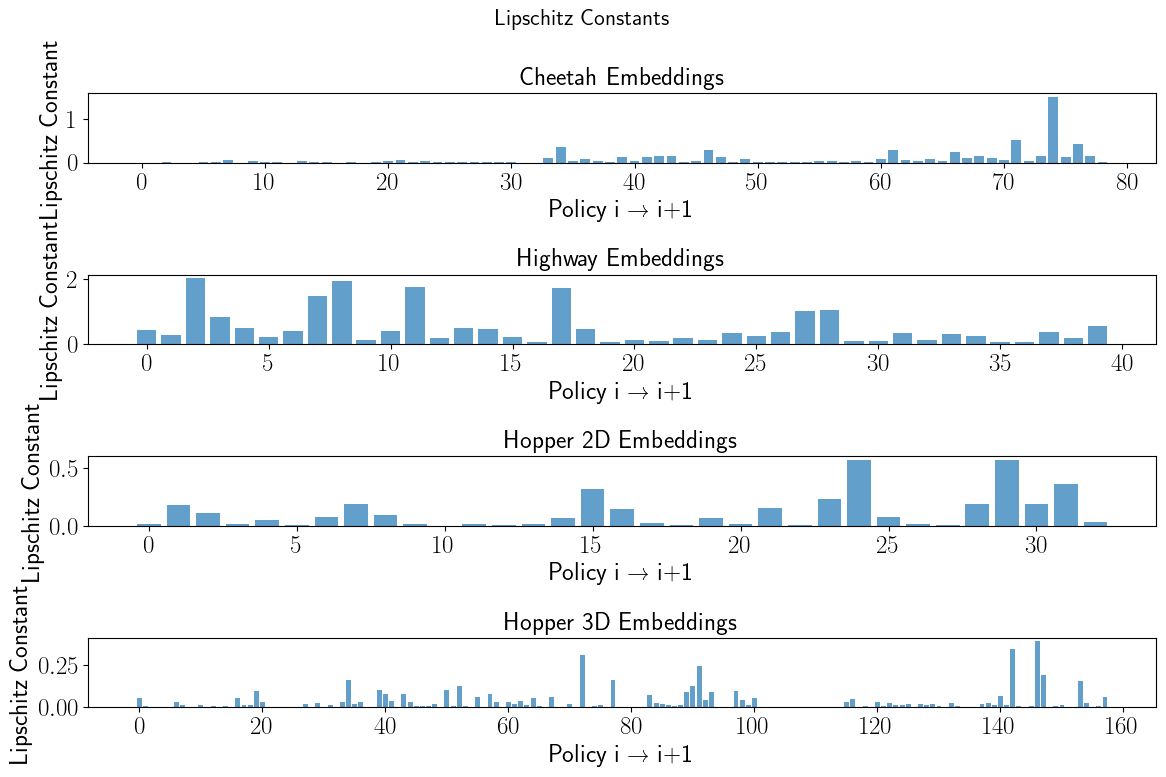

In [ ]:
# Makes a histogram of the Lipschitz constants of the GTE embeddings vs the returns
from morl_behavior_objective.analysis.utils_analysis import compute_lipschitz_constants
from morl_behavior_objective.analysis.utils_analysis import compute_lipschitz_constants_3d

lipschitz_constants_highway, d_objs_highway, d_embs_highway, sorted_pf_highway, sorted_emb_highway = (
    compute_lipschitz_constants_3d(pareto_frontier=returns_highway, embeddings=all_t_emb_high)
)
lipschitz_constants_cheetah, d_objs_cheetah, d_embs_cheetah, sorted_pf_cheetah, sorted_emb_cheetah = (
    compute_lipschitz_constants(pareto_frontier=returns, embeddings=all_t_emb_cheetah)
)


lipschitz_constants_hopper_2d, d_objs_hopper_2d, d_embs_hopper_2d, sorted_pf_hopper_2d, sorted_emb_hopper_2d = (
    compute_lipschitz_constants(pareto_frontier=returns_hopper_2d, embeddings=all_t_emb_hopper_2d)
)
lipschitz_constants_hopper_3d, d_objs_hopper_3d, d_embs_hopper_3d, sorted_pf_hopper_3d, sorted_emb_hopper_3d = (
    compute_lipschitz_constants_3d(pareto_frontier=returns_hopper_3d, embeddings=all_t_emb_hopper_3d)
)

fig, axs = plt.subplots(4, figsize=(12, 8))

fig.suptitle("Lipschitz Constants ", fontsize=16)
axs[0].bar(np.arange(len(lipschitz_constants_cheetah)), lipschitz_constants_cheetah, alpha=0.7)
axs[0].set_title("Cheetah Embeddings")
axs[0].set_ylabel("Lipschitz Constant")
axs[0].set_xlabel("Policy i → i+1")

axs[1].bar(np.arange(len(lipschitz_constants_highway)), lipschitz_constants_highway, alpha=0.7)
axs[1].set_title("Highway Embeddings")
axs[1].set_ylabel("Lipschitz Constant")
axs[1].set_xlabel("Policy i → i+1")

axs[2].bar(np.arange(len(lipschitz_constants_hopper_2d)), lipschitz_constants_hopper_2d, alpha=0.7)
axs[2].set_title("Hopper 2D Embeddings")
axs[2].set_ylabel("Lipschitz Constant")
axs[2].set_xlabel("Policy i → i+1")

axs[3].bar(np.arange(len(lipschitz_constants_hopper_3d)), lipschitz_constants_hopper_3d, alpha=0.7)
axs[3].set_title("Hopper 3D Embeddings")
axs[3].set_ylabel("Lipschitz Constant")
axs[3].set_xlabel("Policy i → i+1")

plt.tight_layout()
plt.show()

## Cheetah analysis

In [ ]:
# get policies with the highest lipshitz jump
import numpy as np

sorted_idx = np.argsort(lipschitz_constants_cheetah)
highest_pairs = [[f, f + 1] for f in sorted_idx[-2:]]
print(highest_pairs)
org_policy_id = np.lexsort(returns.T)[highest_pairs[-1]]
render_policy(
    env_id="mo-halfcheetah-v5",
    check_point="MORL_policies/morld_cheetah_v5/seed0.tar",
    policy_id=org_policy_id[0],
    n_episodes=5,
    save_dic="videos/half-cheetah/highest",
    base_path="../..",
)
render_policy(
    env_id="mo-halfcheetah-v5",
    check_point="MORL_policies/morld_cheetah_v5/seed0.tar",
    policy_id=org_policy_id[1],
    n_episodes=5,
    save_dic="videos/half-cheetah/highest",
    base_path="../..",
)

[[71, 72], [74, 75]]
Weights: [[0.         1.        ]
 [0.19917259 0.80082741]
 [0.39978924 0.60021076]
 [0.60048042 0.39951958]
 [0.80099882 0.19900118]
 [1.         0.        ]]
Neighborhoods: [[1], [0], [1], [4], [5], [4]]
[MORLD] mo-halfcheetah-v5: rendering policy 10 with weights [0.19917259 0.80082741]
Weights: [[0.         1.        ]
 [0.19917259 0.80082741]
 [0.39978924 0.60021076]
 [0.60048042 0.39951958]
 [0.80099882 0.19900118]
 [1.         0.        ]]
Neighborhoods: [[1], [0], [1], [4], [5], [4]]
[MORLD] mo-halfcheetah-v5: rendering policy 7 with weights [0.19917259 0.80082741]


In [ ]:
# Get policies with the  secondhighest Lipschitz constants
import numpy as np

sorted_idx = np.argsort(lipschitz_constants_cheetah)
highest_pairs = [[f, f + 1] for f in sorted_idx[-2:]]
highest_pairs[-1]
# see what policies these correspond to in the original pareto front
org_policy_id = np.lexsort(returns.T)[highest_pairs[-2]]
render_policy(
    env_id="mo-halfcheetah-v4",
    check_point="MORL_policies/morld_cheetah_v5/seed0.tar",
    policy_id=org_policy_id[0],
    n_episodes=5,
    save_dic="videos/half-cheetah/second_highest",
    base_path="../..",
)
render_policy(
    env_id="mo-halfcheetah-v4",
    check_point="MORL_policies/morld_cheetah_v5/seed0.tar",
    policy_id=org_policy_id[1],
    n_episodes=5,
    save_dic="videos/half-cheetah/second_highest",
    base_path="../..",
)

/Users/ffelte/Documents/Behavior-vs-Objective-Space/venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment mo-halfcheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


Weights: [[0.         1.        ]
 [0.19917259 0.80082741]
 [0.39978924 0.60021076]
 [0.60048042 0.39951958]
 [0.80099882 0.19900118]
 [1.         0.        ]]
Neighborhoods: [[1], [0], [1], [4], [5], [4]]
[MORLD] mo-halfcheetah-v4: rendering policy 13 with weights [0.19917259 0.80082741]
Weights: [[0.         1.        ]
 [0.19917259 0.80082741]
 [0.39978924 0.60021076]
 [0.60048042 0.39951958]
 [0.80099882 0.19900118]
 [1.         0.        ]]
Neighborhoods: [[1], [0], [1], [4], [5], [4]]
[MORLD] mo-halfcheetah-v4: rendering policy 17 with weights [0.19917259 0.80082741]


In [ ]:
# lowest
import numpy as np

sorted_idx = np.argsort(lipschitz_constants_cheetah)
highest_pairs = [[f, f + 1] for f in sorted_idx[:]]
highest_pairs[0]
# see what policies these correspond to in the original pareto front
org_policy_id = np.lexsort(returns.T)[highest_pairs[0]]
print(highest_pairs)
render_policy(
    env_id="mo-halfcheetah-v4",
    check_point="MORL_policies/morld_cheetah_v5/seed0.tar",
    policy_id=org_policy_id[0],
    n_episodes=5,
    save_dic="videos/half-cheetah/lowest",
    base_path="../..",
)
render_policy(
    env_id="mo-halfcheetah-v4",
    check_point="MORL_policies/morld_cheetah_v5/seed0.tar",
    policy_id=org_policy_id[1],
    n_episodes=5,
    save_dic="videos/half-cheetah/lowest",
    base_path="../..",
)

[[0, 1], [4, 5], [1, 2], [18, 19], [8, 9], [31, 32], [3, 4], [12, 13], [32, 33], [16, 17], [26, 27], [38, 39], [28, 29], [10, 11], [5, 6], [6, 7], [15, 16], [22, 23], [17, 18], [53, 54], [27, 28], [29, 30], [2, 3], [11, 12], [25, 26], [57, 58], [19, 20], [78, 79], [50, 51], [59, 60], [51, 52], [14, 15], [44, 45], [52, 53], [48, 49], [30, 31], [54, 55], [24, 25], [20, 21], [13, 14], [65, 66], [37, 38], [63, 64], [9, 10], [40, 41], [72, 73], [56, 57], [45, 46], [55, 56], [23, 24], [35, 36], [58, 59], [7, 8], [70, 71], [21, 22], [62, 63], [49, 50], [36, 37], [60, 61], [64, 65], [67, 68], [69, 70], [33, 34], [39, 40], [75, 76], [47, 48], [41, 42], [77, 78], [42, 43], [73, 74], [43, 44], [68, 69], [66, 67], [46, 47], [61, 62], [34, 35], [76, 77], [71, 72], [74, 75]]
Weights: [[0.         1.        ]
 [0.19917259 0.80082741]
 [0.39978924 0.60021076]
 [0.60048042 0.39951958]
 [0.80099882 0.19900118]
 [1.         0.        ]]
Neighborhoods: [[1], [0], [1], [4], [5], [4]]
[MORLD] mo-halfcheetah

In [ ]:
import numpy as np

sorted_idx = np.argsort(lipschitz_constants_cheetah)
highest_pairs = [[f, f + 1] for f in sorted_idx[:]]
highest_pairs[0]

[0, 1]

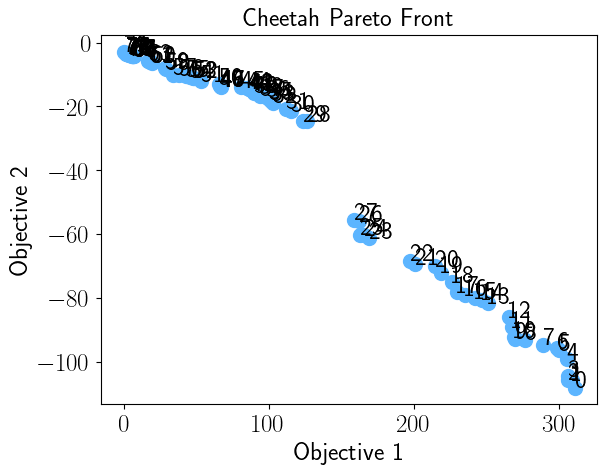

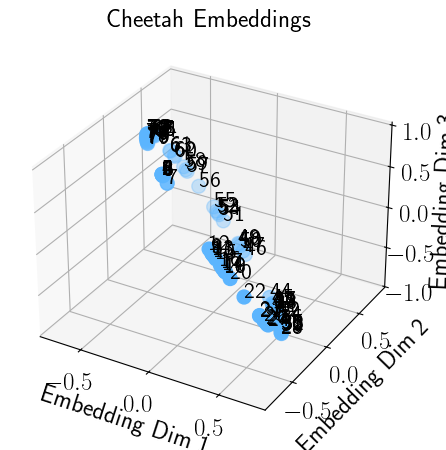

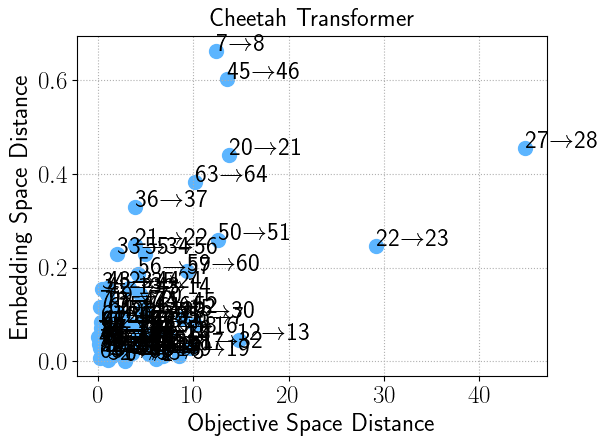

In [ ]:
plt.scatter(sorted_pf_cheetah[:, 0], sorted_pf_cheetah[:, 1], c=colors[0], s=100)
plt.xlabel("Objective 1")
plt.ylabel("Objective 2")
for i, txt in enumerate(range(len(sorted_pf_cheetah))):
    plt.annotate(f"{i}", (sorted_pf_cheetah[i, 0], sorted_pf_cheetah[i, 1]))
plt.title("Cheetah Pareto Front")
plt.show()

# plot cheetah embeddings in 3d
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(sorted_emb_cheetah[:, 0], sorted_emb_cheetah[:, 1], sorted_emb_cheetah[:, 2], c=colors[0], s=100)
for i, txt in enumerate(range(len(sorted_emb_cheetah))):
    ax.text(sorted_emb_cheetah[i, 0], sorted_emb_cheetah[i, 1], sorted_emb_cheetah[i, 2], f"{i}", fontsize=16, color="k")
ax.set_xlabel("Embedding Dim 1")
ax.set_ylabel("Embedding Dim 2")
ax.set_zlabel("Embedding Dim 3")
plt.title("Cheetah Embeddings")
plt.tight_layout()
plt.show()

# make a scatter plot where the x axis are the distances in the objective space and the y axis are the distances in the embedding space
plt.scatter(d_objs_cheetah, d_embs_cheetah, c=colors[0], s=100)
plt.xlabel("Objective Space Distance")
plt.ylabel("Embedding Space Distance")
plt.title("Cheetah Transformer")

# add index as text labels
for i, txt in enumerate(range(len(d_objs_cheetah))):
    plt.annotate(f"{i}" + r"$\rightarrow$" + f"{i + 1}", (d_objs_cheetah[i], d_embs_cheetah[i]))

plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()

## Analysis Hopper


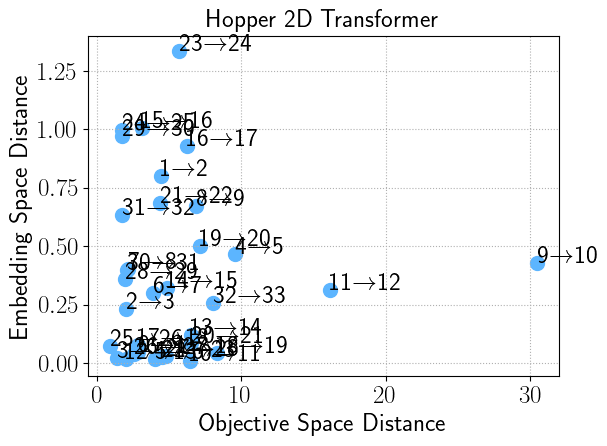

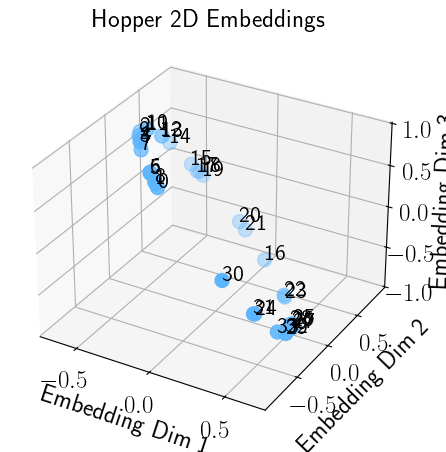

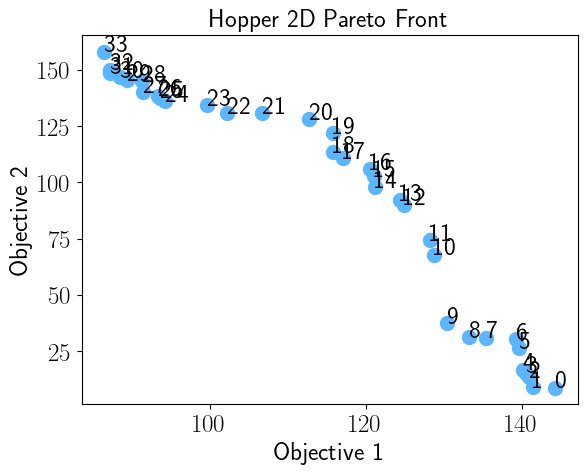

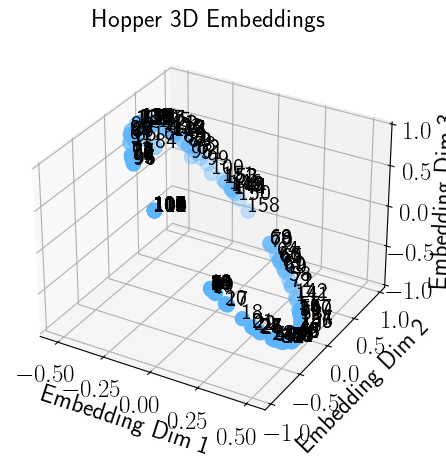

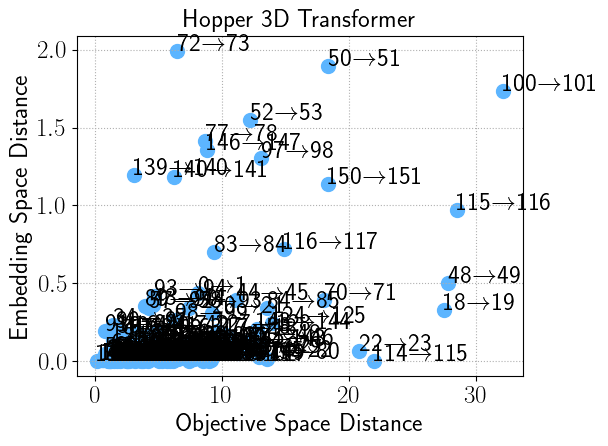

In [ ]:
# make a scatter plot where the x axis are the distances in the objective space and the y axis are the distances in the embedding space
plt.scatter(d_objs_hopper_2d, d_embs_hopper_2d, c=colors[0], s=100)
plt.xlabel("Objective Space Distance")
plt.ylabel("Embedding Space Distance")
plt.title("Hopper 2D Transformer")

# add pair labels
for i, txt in enumerate(range(len(d_objs_hopper_2d))):
    plt.annotate(f"{i}" + r"$\rightarrow$" + f"{i + 1}", (d_objs_hopper_2d[i], d_embs_hopper_2d[i]))

plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()

# plot hopper embeddings in 3d
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(sorted_emb_hopper_2d[:, 0], sorted_emb_hopper_2d[:, 1], sorted_emb_hopper_2d[:, 2], c=colors[0], s=100)
for i, txt in enumerate(range(len(sorted_emb_hopper_2d))):
    ax.text(
        sorted_emb_hopper_2d[i, 0], sorted_emb_hopper_2d[i, 1], sorted_emb_hopper_2d[i, 2], f"{i}", fontsize=16, color="k"
    )
ax.set_xlabel("Embedding Dim 1")
ax.set_ylabel("Embedding Dim 2")
ax.set_zlabel("Embedding Dim 3")
plt.title("Hopper 2D Embeddings")
plt.tight_layout()
plt.show()

# plot hopper pf
plt.scatter(sorted_pf_hopper_2d[:, 0], sorted_pf_hopper_2d[:, 1], c=colors[0], s=100)
plt.xlabel("Objective 1")
plt.ylabel("Objective 2")
for i, txt in enumerate(range(len(sorted_pf_hopper_2d))):
    plt.annotate(f"{i}", (sorted_pf_hopper_2d[i, 0], sorted_pf_hopper_2d[i, 1]))
plt.title("Hopper 2D Pareto Front")

plt.show()

# plot hopper embeddings in 3d
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(sorted_emb_hopper_3d[:, 0], sorted_emb_hopper_3d[:, 1], sorted_emb_hopper_3d[:, 2], c=colors[0], s=100)
for i, txt in enumerate(range(len(sorted_emb_hopper_3d))):
    ax.text(
        sorted_emb_hopper_3d[i, 0], sorted_emb_hopper_3d[i, 1], sorted_emb_hopper_3d[i, 2], f"{i}", fontsize=16, color="k"
    )
ax.set_xlabel("Embedding Dim 1")
ax.set_ylabel("Embedding Dim 2")
ax.set_zlabel("Embedding Dim 3")
plt.title("Hopper 3D Embeddings")
plt.tight_layout()
plt.show()

# make a scatter plot where the x axis are the distances in the objective space and the y axis are the distances in the embedding space
# TODO remove the point at index 139 -- CLEAN THIS UP
d_objs_hopper_3d = np.delete(d_objs_hopper_3d, 139)
d_embs_hopper_3d = np.delete(d_embs_hopper_3d, 139)

plt.scatter(d_objs_hopper_3d, d_embs_hopper_3d, c=colors[0], s=100)
plt.xlabel("Objective Space Distance")
plt.ylabel("Embedding Space Distance")
plt.title("Hopper 3D Transformer")


# add pair labels
for i, txt in enumerate(range(len(d_objs_hopper_3d))):
    plt.annotate(f"{i}" + r"$\rightarrow$" + f"{i + 1}", (d_objs_hopper_3d[i], d_embs_hopper_3d[i]))
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()

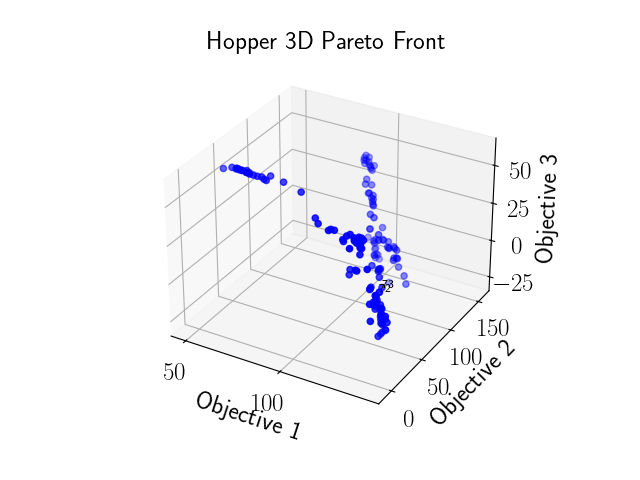

In [ ]:
# Hopper 3D Pareto Front 3D  scatter plot
%matplotlib widget
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(sorted_pf_hopper_3d[:, 0], sorted_pf_hopper_3d[:, 1], sorted_pf_hopper_3d[:, 2], c=colors[0], s=100)
ax.set_xlabel("Objective 1")
ax.set_ylabel("Objective 2")
ax.set_zlabel("Objective 3")
plt.title("Hopper 3D Pareto Front")
for i, txt in enumerate(range(len(sorted_pf_hopper_3d))):
    if i in {72, 73}:
        ax.text(
            sorted_pf_hopper_3d[i, 0], sorted_pf_hopper_3d[i, 1], sorted_pf_hopper_3d[i, 2], f"{i}", fontsize=16, color="k"
        )
plt.show()

## Highway analysis

In [ ]:
# Get policies with the highest Lipschitz constants

sorted_idx = np.argsort(lipschitz_constants_highway)
highest_pairs = [[f, f + 1] for f in sorted_idx[-2:]]
highest_pairs[-1]
# see what policies these correspond to in the original pareto front
org_policy_id = np.lexsort(returns_highway.T)[highest_pairs[-1]]
render_policy(
    env_id="mo-highway-fast-v0",
    check_point="MORL_policies/mo-highway-fast-v0/seed0.tar",
    policy_id=org_policy_id[0],
    n_episodes=5,
    save_dic="videos/highway/highest",
    base_path="../..",
)
render_policy(
    env_id="mo-highway-fast-v0",
    check_point="MORL_policies/mo-highway-fast-v0/seed0.tar",
    policy_id=org_policy_id[1],
    n_episodes=5,
    save_dic="videos/highway/highest",
    base_path="../..",
)

ModuleNotFoundError: No module named 'highway_env'

In [ ]:
# Get policies with the highest Lipschitz constants

sorted_idx = np.argsort(lipschitz_constants_highway)
highest_pairs = [[f, f + 1] for f in sorted_idx[-2:]]
highest_pairs[-1]
# see what policies these correspond to in the original pareto front
org_policy_id = np.lexsort(returns_highway.T)[highest_pairs[-2]]
render_policy(
    env_id="mo-highway-fast-v0",
    check_point="MORL_policies/mo-highway-fast-v0/seed0.tar",
    policy_id=org_policy_id[0],
    n_episodes=5,
    save_dic="videos/highway/second_highest",
    base_path="../..",
)
render_policy(
    env_id="mo-highway-fast-v0",
    check_point="MORL_policies/mo-highway-fast-v0/seed0.tar",
    policy_id=org_policy_id[1],
    n_episodes=5,
    save_dic="videos/highway/second_highest",
    base_path="../..",
)

ModuleNotFoundError: No module named 'highway_env'

(40,)
(40,)


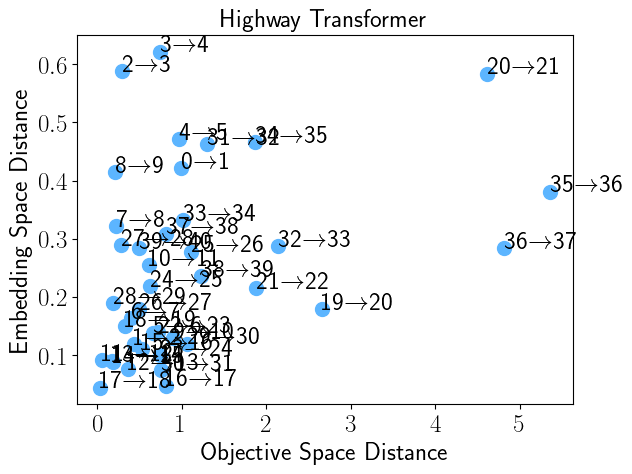

In [ ]:
# make a scatter plot where the x axis are the distances in the objective space and the y axis are the distances in the embedding space
print(d_objs_highway.shape)
print(d_embs_highway.shape)
plt.scatter(d_objs_highway, d_embs_highway, c=colors[0], s=100)
plt.xlabel("Objective Space Distance")
plt.ylabel("Embedding Space Distance")
plt.title("Highway Transformer")
# add index as text labels
for i, txt in enumerate(range(len(d_objs_highway))):
    plt.annotate(f"{i}" + r"$\rightarrow$" + f"{i + 1}", (d_objs_highway[i], d_embs_highway[i]))

plt.show()

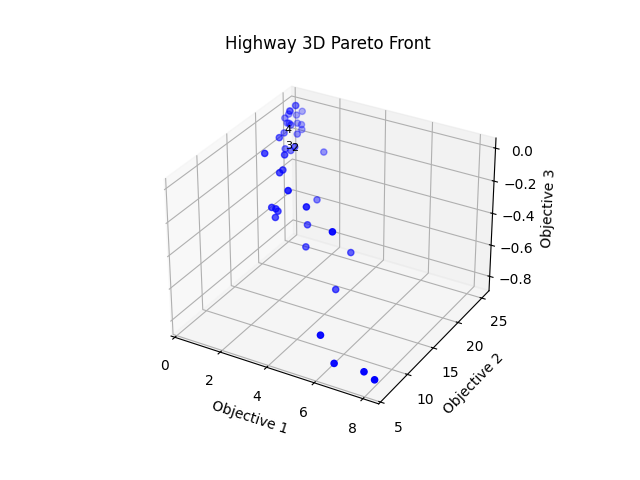

: 

In [ ]:
# Highway Pareto Front 3D  scatter plot
%matplotlib widget
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(sorted_pf_highway[:, 0], sorted_pf_highway[:, 1], sorted_pf_highway[:, 2], c=colors[0], s=100)
ax.set_xlabel("Objective 1")
ax.set_ylabel("Objective 2")
ax.set_zlabel("Objective 3")
plt.title("Highway 3D Pareto Front")
for i, txt in enumerate(range(len(sorted_pf_highway))):
    if i in {3, 4, 2}:
        ax.text(sorted_pf_highway[i, 0], sorted_pf_highway[i, 1], sorted_pf_highway[i, 2], f"{i}", fontsize=16, color="k")
plt.show()